## Check BGC-Argo floats distribution split

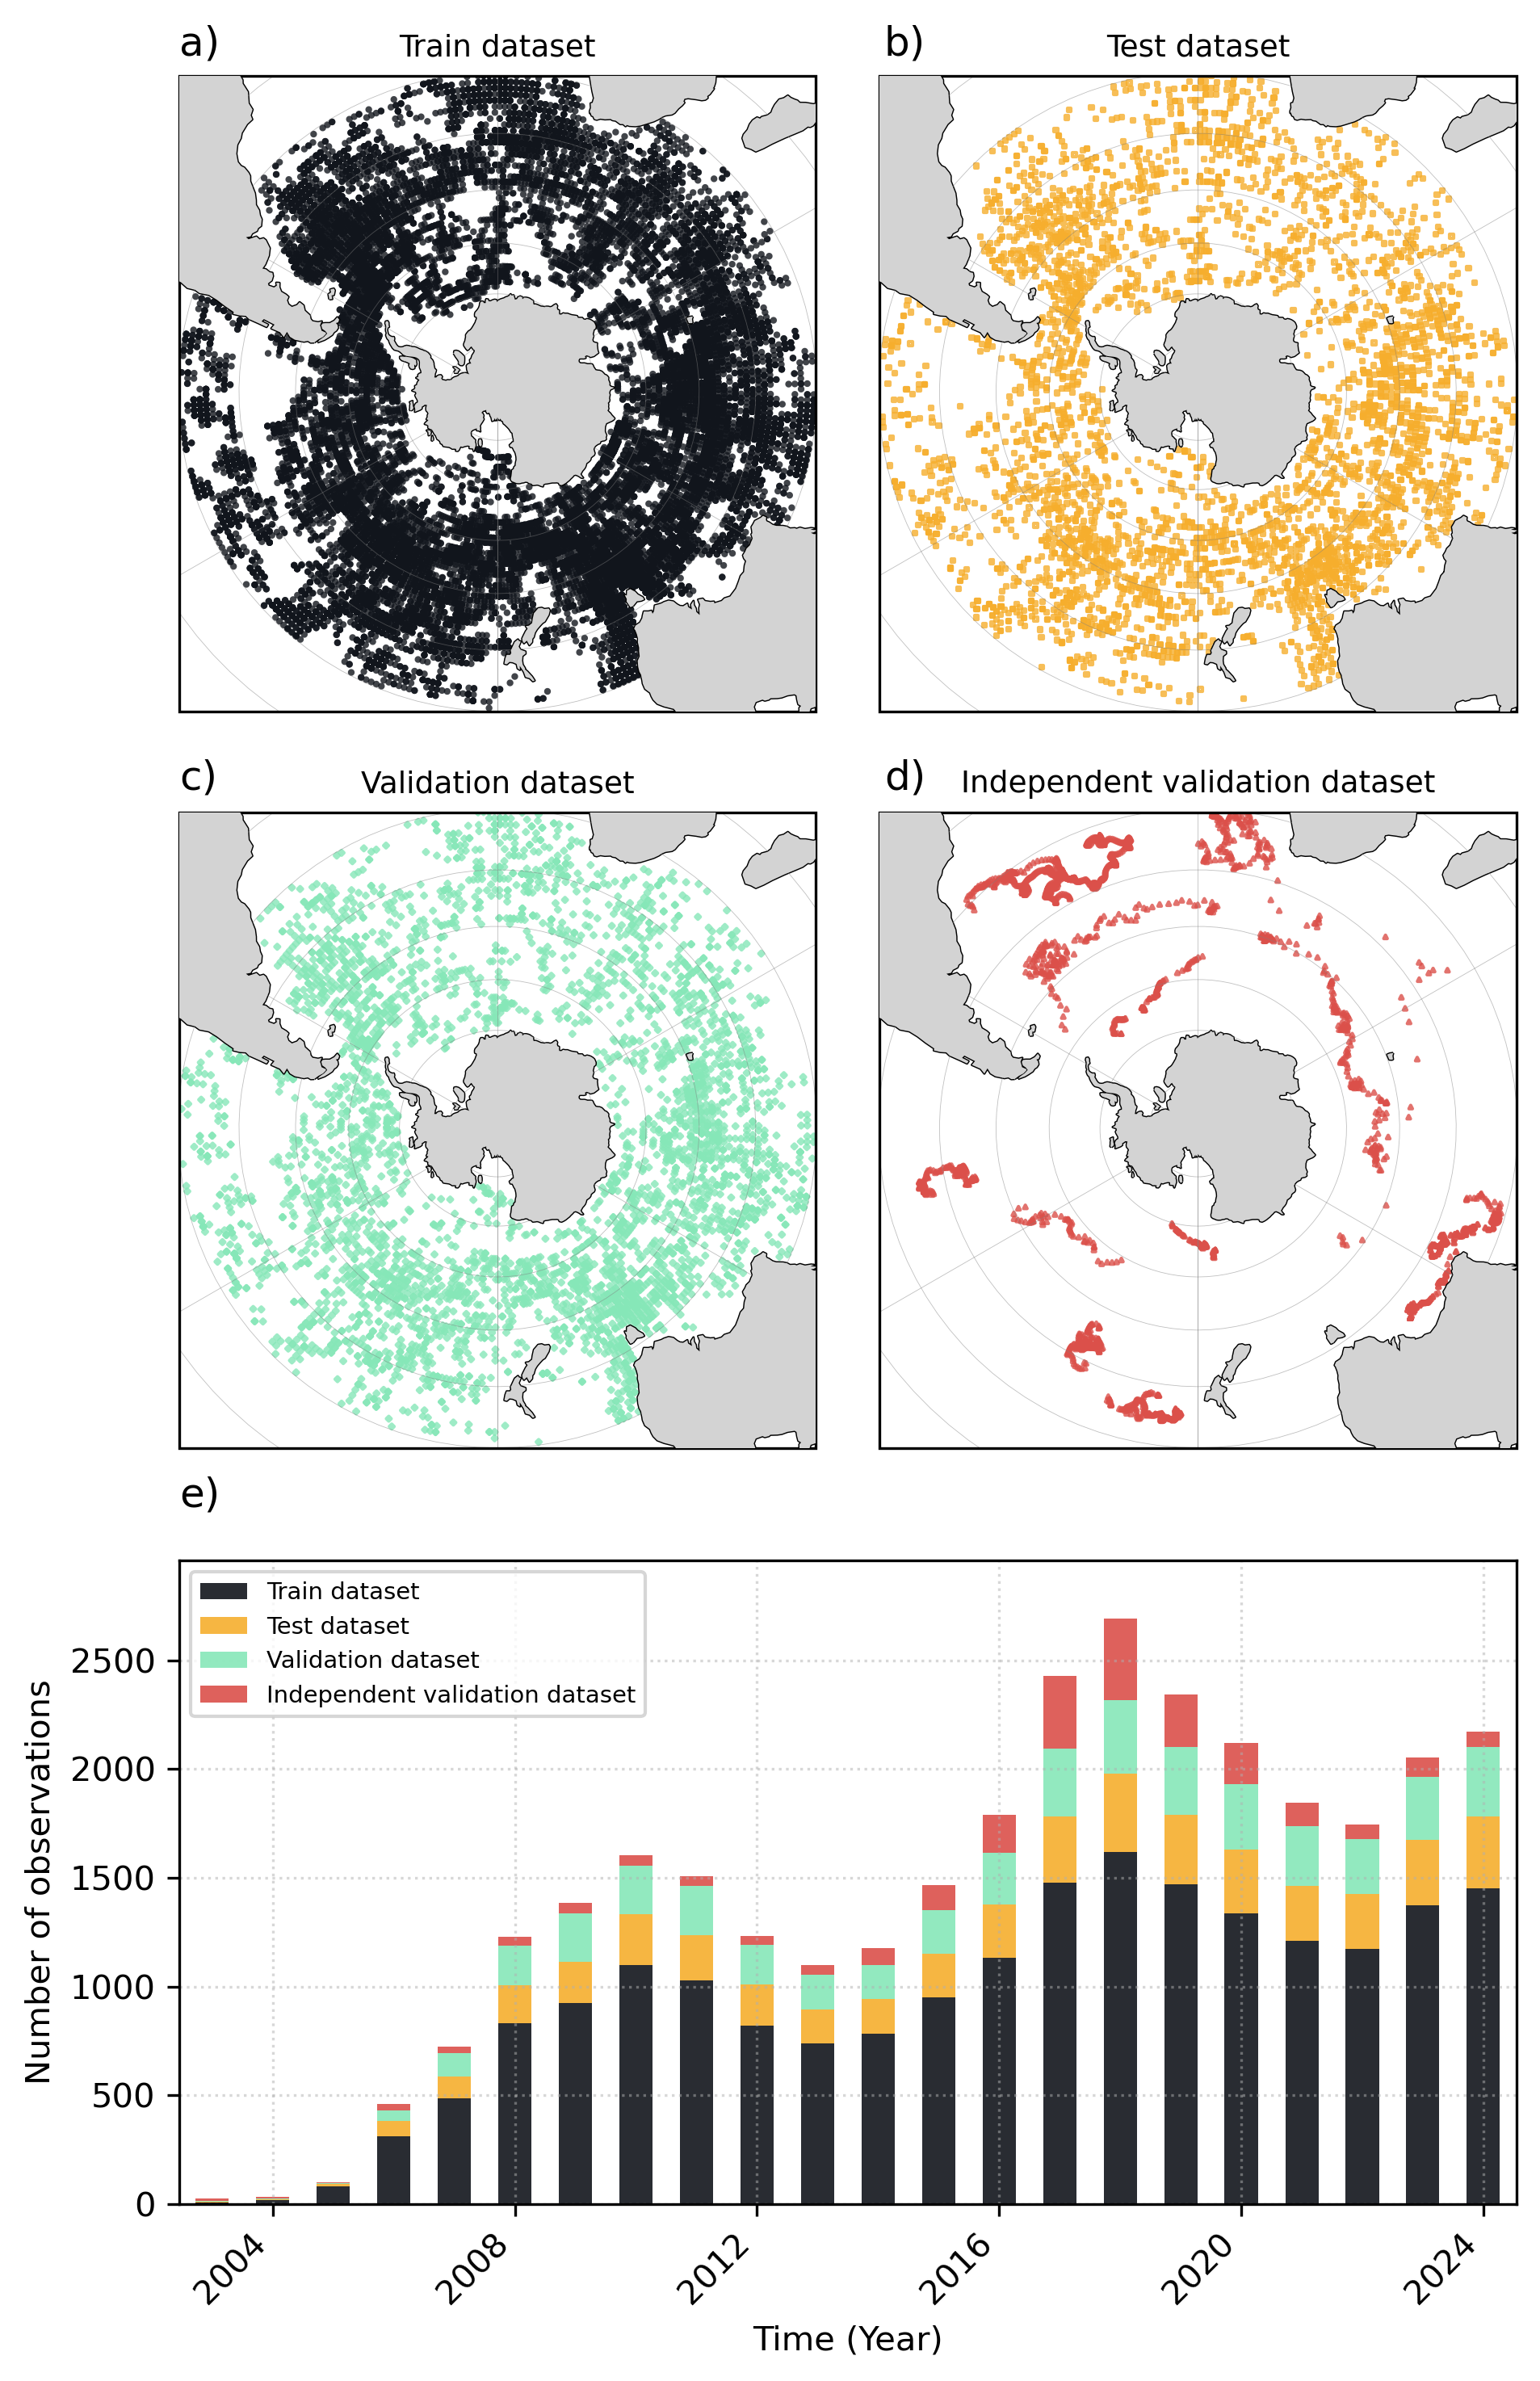

[DONE] Saved figure → figs/HDBSCAN_split_overview.png


In [1]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import os

# ===============================================================
# CONFIG
# ===============================================================
OUTFIG = "figs/HDBSCAN_split_overview.png"
os.makedirs(os.path.dirname(OUTFIG), exist_ok=True)

LAT_EXTENT = [-180, 180, -90, -30]  # map extent

# ===============================================================
# LOAD DATASETS
# ===============================================================
datasets = {
    "train_data": pd.read_csv(
        "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/processing_steps/FLOATS_pco2_train_data.csv"
    ),
    "test_data": pd.read_csv(
        "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/processing_steps/FLOATS_pco2_test_data.csv"
    ),
    "validation_data": pd.read_csv(
        "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/processing_steps/FLOATS_pco2_validation_data.csv"
    ),
    "independent_validation_data": pd.read_csv(
        "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/processing_steps/independent_validation/pco2_independent_validation_data.csv"
    ),
}

# ===============================================================
# FIX COORDINATE COLUMN NAMES
# ===============================================================
for key, df in datasets.items():
    # HDBSCAN splits typically have latitude/longitude already
    if "lat_center" in df.columns and "latitude" not in df.columns:
        df.rename(columns={"lat_center": "latitude"}, inplace=True)
    if "lon_center" in df.columns and "longitude" not in df.columns:
        df.rename(columns={"lon_center": "longitude"}, inplace=True)

# ===============================================================
# ENSURE month_center EXISTS (ROBUST) + NORMALIZE TO MONTH-START
# ===============================================================
for key, df in datasets.items():

    # 1) month_center already exists
    if "month_center" in df.columns:
        df["month_center"] = pd.to_datetime(df["month_center"], errors="coerce")

    # 2) try datetime
    elif "datetime" in df.columns:
        df["month_center"] = pd.to_datetime(df["datetime"], errors="coerce")

    # 3) try time
    elif "time" in df.columns:
        df["month_center"] = pd.to_datetime(df["time"], errors="coerce")

    # 4) build from components if present
    elif {"year", "month", "day"}.issubset(df.columns):
        df["month_center"] = pd.to_datetime(
            dict(year=df["year"], month=df["month"], day=df["day"]),
            errors="coerce"
        )

    else:
        raise ValueError(
            f"{key}: cannot build month_center. Available columns: {list(df.columns)}"
        )

    # Normalize to monthly timestamp (pipeline convention = month-start)
    df["month_center"] = df["month_center"].dt.to_period("M").dt.to_timestamp(how="start")
    df.dropna(subset=["month_center"], inplace=True)

# ===============================================================
# PLOTTING
# ===============================================================
def plot_data(datasets_dict):

    colors = ['#11151C', '#F6AE2D', '#86E7B8', '#DB504A']
    markers = ['o', 's', 'D', '^']
    label_map = {
        "train_data": "Train dataset",
        "test_data": "Test dataset",
        "validation_data": "Validation dataset",
        "independent_validation_data": "Independent validation dataset"
    }

    ordered_keys = ["train_data", "test_data", "validation_data", "independent_validation_data"]

    fig = plt.figure(figsize=(6, 10), dpi=300)
    gs = gridspec.GridSpec(4, 2, height_ratios=[1, 1, -0.12, 1])

    # === MAPS (4 PANELS) ===
    for i, key in enumerate(ordered_keys):
        row, col = divmod(i, 2)

        ax = fig.add_subplot(gs[row, col], projection=ccrs.SouthPolarStereo())
        ax.set_extent(LAT_EXTENT, crs=ccrs.PlateCarree())
        ax.coastlines(resolution='110m', linewidth=0.7)
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=12)
        ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.5)

        df = datasets_dict[key]

        if "latitude" not in df.columns or "longitude" not in df.columns:
            raise ValueError(f"{key} is missing latitude/longitude columns.")

        ax.scatter(
            df["longitude"], df["latitude"],
            s=1,
            facecolors="none",
            edgecolors=colors[i],
            marker=markers[i],
            alpha=0.8,
            transform=ccrs.PlateCarree()
        )

        ax.set_title(label_map[key], fontsize=9)

    # === YEARLY STACKED HISTOGRAM ===
    ax_hist = fig.add_subplot(gs[3, :])

    hist_keys = ordered_keys

    min_year = min(datasets_dict[k]["month_center"].dt.year.min() for k in hist_keys)
    max_year = max(datasets_dict[k]["month_center"].dt.year.max() for k in hist_keys)

    all_years = pd.period_range(start=f"{min_year}", end=f"{max_year}", freq="Y")
    all_years_datetime = all_years.to_timestamp()

    bar_width = 200  # days (wide since yearly)
    bottom = np.zeros(len(all_years_datetime))

    for key, color in zip(hist_keys, colors):
        df = datasets_dict[key]

        yearly_counts = (
            df["month_center"]
            .dt.to_period("Y")
            .value_counts()
            .reindex(all_years, fill_value=0)
            .sort_index()
        )

        ax_hist.bar(
            all_years_datetime,
            yearly_counts.values,
            width=bar_width,
            bottom=bottom,
            color=color,
            alpha=0.9,
            label=label_map[key]
        )
        bottom += yearly_counts.values

    ax_hist.set_xlim(
        all_years_datetime.min() - pd.Timedelta(days=200),
        all_years_datetime.max() + pd.Timedelta(days=200)
    )

    ymax = bottom.max()
    ax_hist.set_ylim(0, ymax * 1.1 if ymax > 0 else 1)

    ax_hist.set_xlabel("Time (Year)")
    ax_hist.set_ylabel("Number of observations")
    ax_hist.grid(True, linestyle=":", alpha=0.5)
    ax_hist.legend(loc="upper left", fontsize=7)

    plt.setp(ax_hist.get_xticklabels(), rotation=45, ha="right")

    # === PANEL TAGS ===
    tags = ["a)", "b)", "c)", "d)", "e)"]
    positions = [
        (0.05, 0.967), (0.535, 0.967),
        (0.05, 0.664), (0.535, 0.664),
        (0.05, 0.368)
    ]
    for (x, y), tag in zip(positions, tags):
        fig.text(x, y, tag, fontsize=12)

    plt.subplots_adjust(left=0.05, right=0.97, top=0.96, bottom=0.08, wspace=0.1)

    plt.savefig(OUTFIG, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[DONE] Saved figure → {OUTFIG}")


plot_data(datasets)


In [18]:
datasets["train_data"]

,month_center,latitude,longitude,depth,MLD,ARMOR3D_temperature,ARMOR3D_salinity,FLOATS_pco2_median,FLOATS_pco2_error_median,FLOATS_temperature_median,...,decimal_year,doy_radians,doy_sin,doy_cos,x_cart,y_cart,z_cart,bottom_depth_m,days_since_start,cluster
0,2020-01-01,-56.5,35.5,0.0,29.20,1.8835,33.7695,364.244000,20.657000,1.598000,...,2020.000000,0.017214,0.017213,0.999852,0.449340,0.320511,-0.833886,5358,6209.0,-1
1,2019-07-01,-39.5,-176.5,0.0,118.45,14.1635,35.2350,371.590985,25.044001,13.860000,...,2019.495890,3.132986,0.008607,-0.999963,-0.770185,-0.047107,-0.636078,3992,6025.0,-1
2,2021-12-01,-48.5,15.5,0.0,50.00,4.3275,33.8610,394.915509,24.189875,4.878250,...,2021.915068,5.766759,-0.493776,0.869589,0.638521,0.177078,-0.748956,4575,6909.0,-1
3,2010-12-01,-58.5,166.5,0.0,76.45,4.1475,33.8565,357.361005,21.639999,3.992000,...,2010.915068,5.766759,-0.493776,0.869589,-0.508062,0.121975,-0.852640,4954,2891.0,182
4,2017-12-01,-47.5,-17.5,0.0,46.65,7.1075,33.8860,382.794995,20.731001,8.712663,...,2017.915068,5.766759,-0.493776,0.869589,0.644322,-0.203154,-0.737277,3500,5448.0,277
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20323,2021-04-01,-39.5,100.5,0.0,53.30,14.8580,35.0090,386.143994,26.705000,14.834000,...,2021.246575,1.566493,0.999991,0.004304,-0.140617,0.758704,-0.636078,4201,6665.0,399
20324,2008-04-01,-41.5,153.5,0.0,56.95,16.8010,35.4420,329.035992,17.981499,16.981501,...,2008.248634,1.583707,0.999917,-0.012910,-0.670266,0.334182,-0.662620,4777,1917.0,213
20325,2018-02-01,-55.5,78.5,0.0,46.75,2.0630,33.8775,390.167920,21.178318,2.823509,...,2018.084932,0.550855,0.523416,0.852078,0.112923,0.555035,-0.824126,2213,5510.0,377
20326,2010-12-01,-61.5,102.5,0.0,16.85,-0.6295,33.7520,339.684003,21.115999,-1.429250,...,2010.915068,5.766759,-0.493776,0.869589,-0.103276,0.465848,-0.878817,4283,2891.0,53


## BGC-Argo independent validation

In [2]:
import pandas as pd

df = pd.read_csv(
    "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/MODEL_FLOATS_v2/models/30S/MC_ensemble/independent_predictions/MC_FLOATS_independent_validation_predictions.csv"
)

In [3]:
df

,month_center,lat_center,lon_center,depth,MLD,ARMOR3D_temperature,ARMOR3D_salinity,FLOATS_pco2_median,FLOATS_pco2_error_median,FLOATS_temperature_median,...,pco2_pred_MCmodel_992,pco2_pred_MCmodel_993,pco2_pred_MCmodel_994,pco2_pred_MCmodel_995,pco2_pred_MCmodel_996,pco2_pred_MCmodel_997,pco2_pred_MCmodel_998,pco2_pred_MCmodel_999,pco2_pred_MCmodel_1000,ensemble_std
0,2003-09-01,-35.5,-162.5,0.0,53.45,15.0620,35.2185,335.831494,18.259001,15.380500,...,344.05570,342.02292,346.41780,338.45630,336.26425,330.48944,341.30103,336.63367,343.83480,5.877133
1,2003-10-01,-35.5,-162.5,0.0,57.25,15.1555,35.1665,333.719983,18.228001,15.775000,...,350.46457,346.04053,338.53520,338.94144,342.65150,337.68637,335.58823,333.79443,341.73680,6.147455
2,2003-08-01,-35.5,-161.5,0.0,93.10,14.6435,35.1210,335.939999,18.066750,15.361249,...,341.80610,343.82758,347.21600,343.26788,343.43466,336.10828,345.86395,345.39142,346.15726,6.010860
3,2003-09-01,-35.5,-161.5,0.0,68.65,14.9390,35.1900,333.817761,17.990501,15.275500,...,345.90903,341.26636,344.32030,339.52545,336.69473,329.69772,341.00180,336.10780,343.29904,5.769576
4,2003-10-01,-35.5,-161.5,0.0,37.70,15.3255,35.1340,333.253003,18.209999,15.927500,...,347.48883,347.10980,337.84842,336.48492,342.50684,340.79294,336.03915,333.42798,340.34464,6.258643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1142,2024-01-01,-30.5,-36.5,0.0,23.50,22.6340,35.8940,418.807996,25.484000,22.176453,...,418.74966,410.31640,407.53210,414.77823,425.75864,428.56116,410.23294,423.64540,429.11087,8.888896
1143,2024-02-01,-30.5,-36.5,0.0,19.30,23.7910,35.7905,426.201001,25.327999,23.560463,...,430.16742,428.52620,422.08563,427.55970,437.66733,446.51492,418.19170,437.74560,437.97412,8.110567
1144,2024-03-01,-30.5,-36.5,0.0,26.40,24.0830,35.8870,429.335004,25.938999,24.403641,...,436.76540,438.16754,432.53490,423.07336,435.04715,459.78020,421.63840,440.26953,432.84198,8.259949
1145,2024-04-01,-30.5,-36.5,0.0,40.95,22.9715,36.0405,419.728986,26.481001,22.896458,...,432.30700,423.33066,424.97406,413.15112,416.23636,448.71625,411.69492,427.30054,421.14910,8.235634


Years present: [2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016
 2017 2018 2019 2020 2021 2022 2023 2024]


/home/ldelaigue/.conda/envs/soca/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  result = super().scatter(*args, **kwargs)
/home/ldelaigue/.conda/envs/soca/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  result = super().scatter(*args, **kwargs)
/home/ldelaigue/.conda/envs/soca/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('1').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  result = super().scatter(*args, **kwargs)
/home/ldelaigue/.co

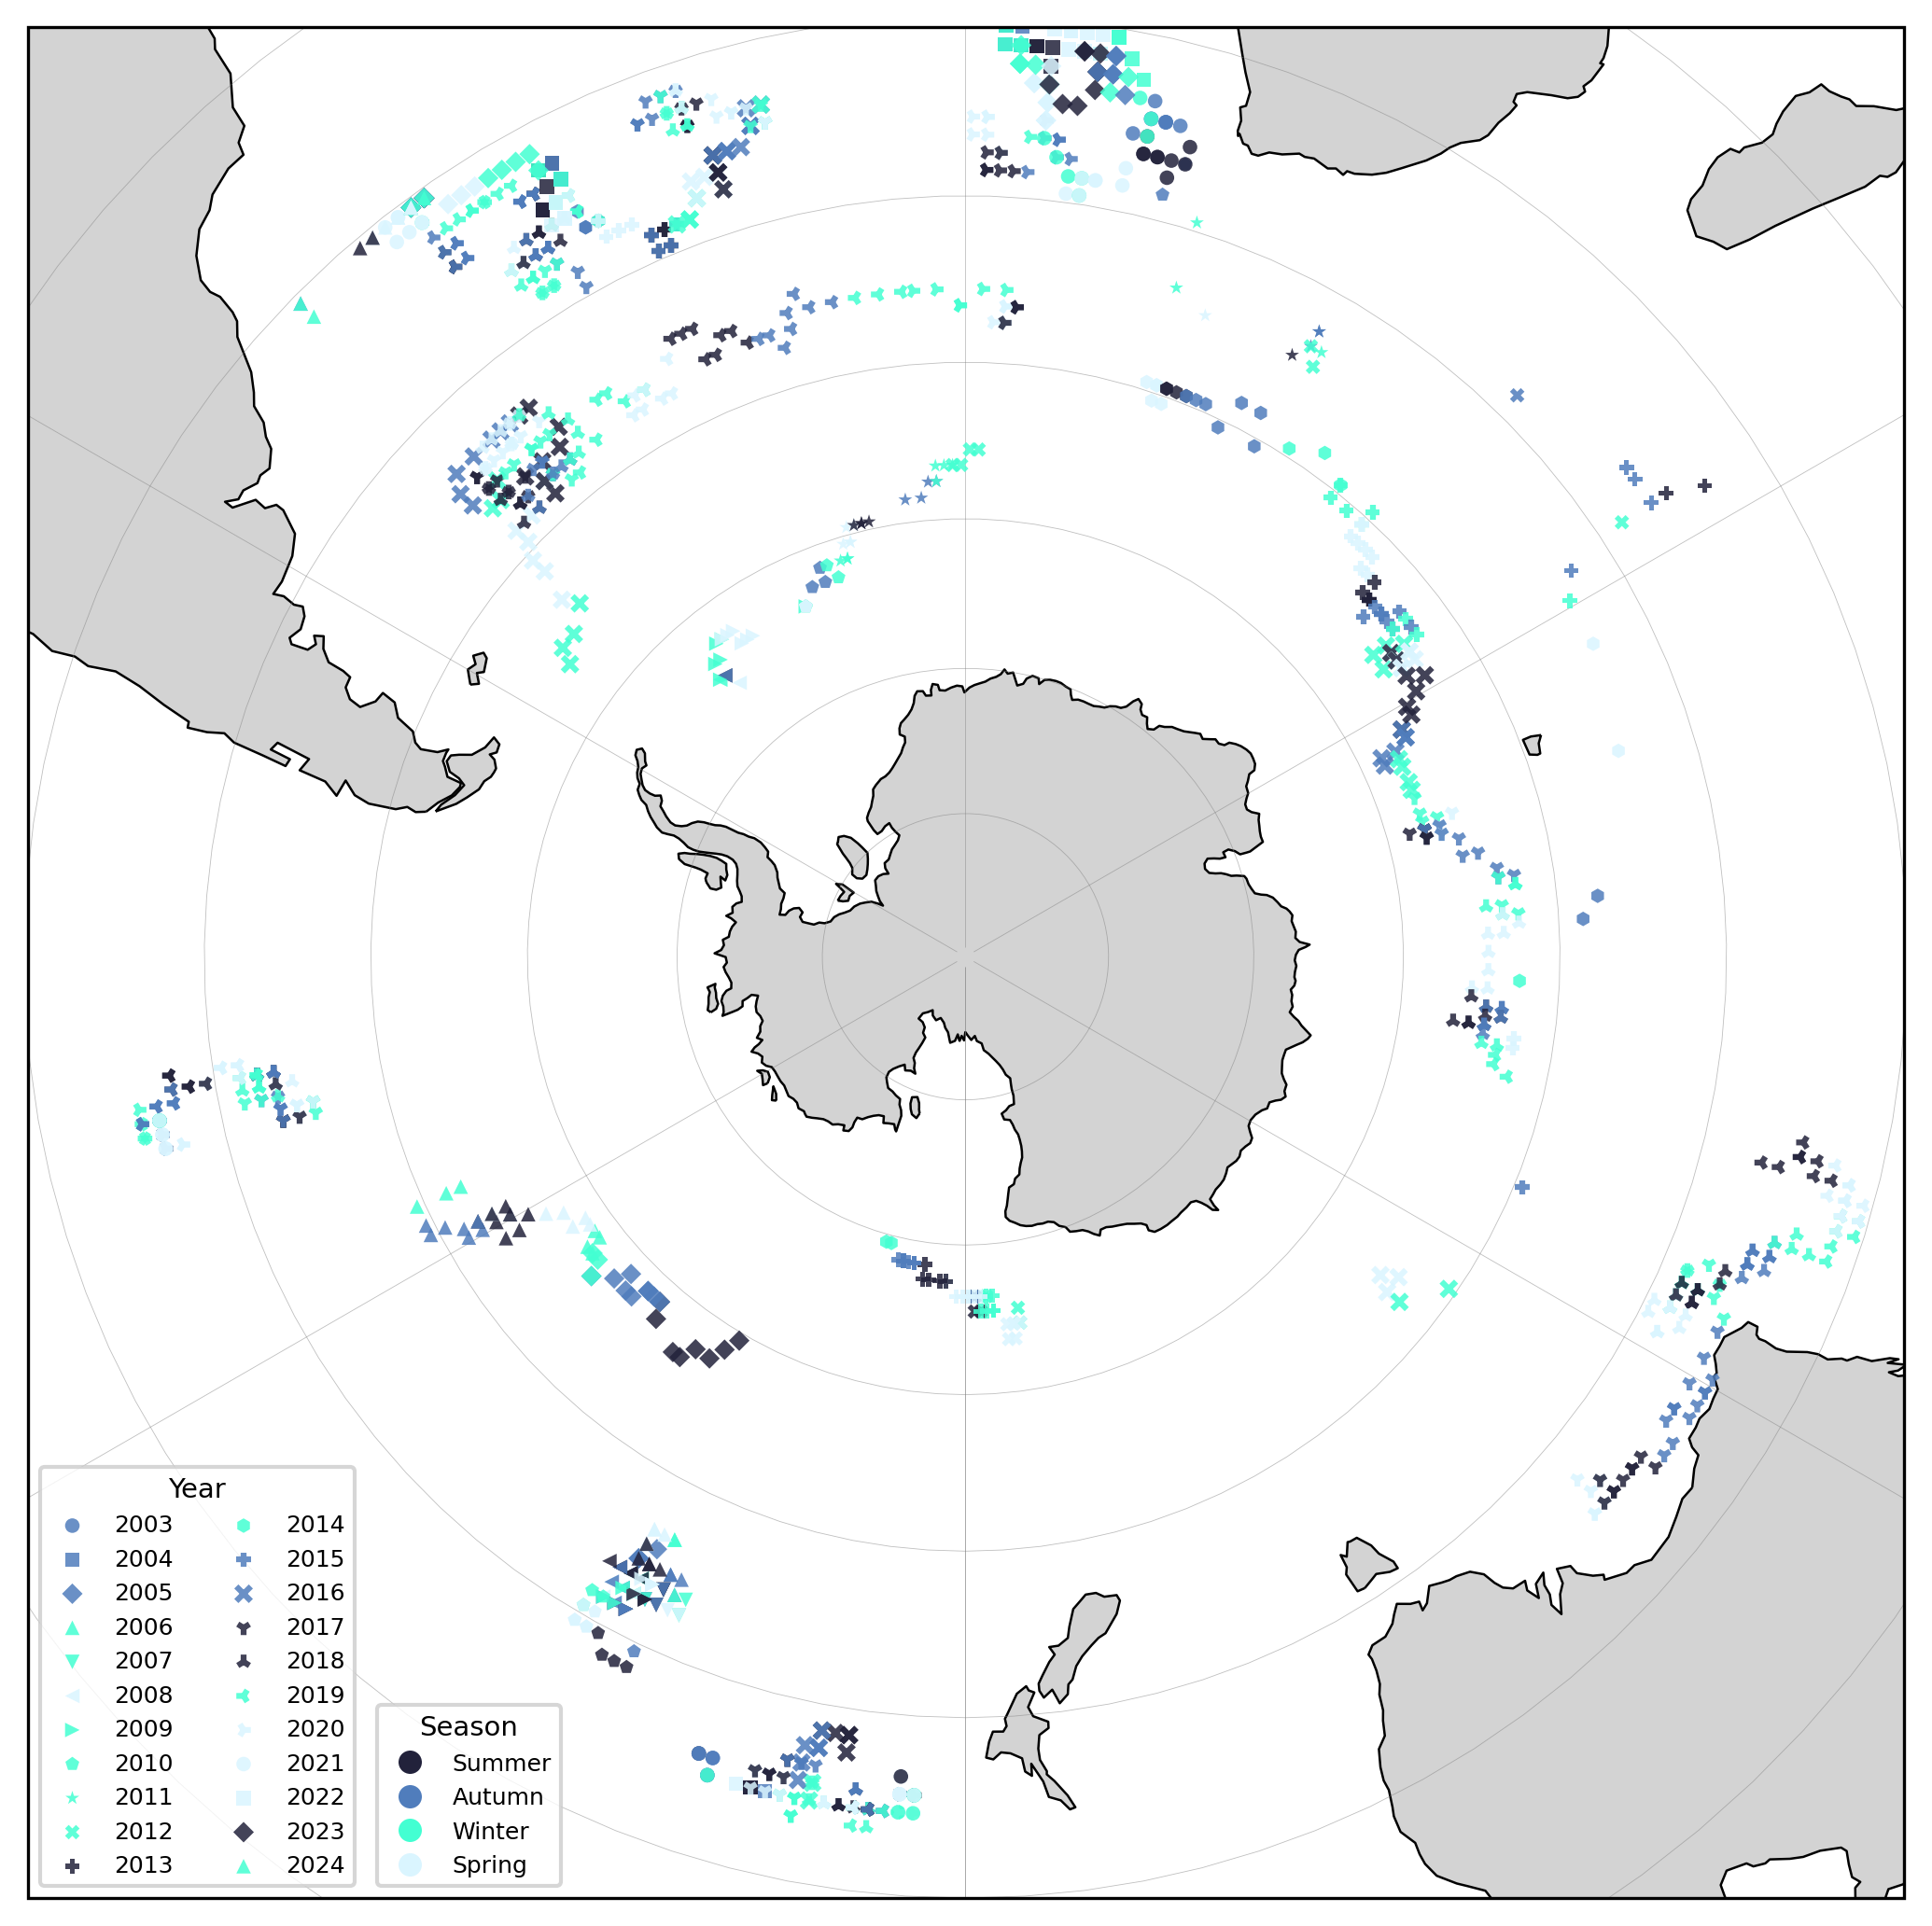

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.lines import Line2D

# -------------------------------
# Convert month_center to datetime
# -------------------------------
df["month_center"] = pd.to_datetime(df["month_center"], errors="coerce")
df["year"] = df["month_center"].dt.year
df["month"] = df["month_center"].dt.month

# -------------------------------
# Month → season
# -------------------------------
def month_to_season(month):
    if month in (12, 1, 2):
        return "Winter"
    elif month in (3, 4, 5):
        return "Spring"
    elif month in (6, 7, 8):
        return "Summer"
    elif month in (9, 10, 11):
        return "Autumn"
    return np.nan

df["season"] = df["month"].apply(
    lambda m: month_to_season(int(m)) if pd.notna(m) else np.nan
)

# -------------------------------
# Drop rows with missing info
# -------------------------------
df = df.dropna(subset=["year", "season", "lat_center", "lon_center"])

# -------------------------------
# Years present
# -------------------------------
years = np.sort(df["year"].unique())
print("Years present:", years)

# -------------------------------
# Season colors
# -------------------------------
season_colors = {
    "Summer": "#22223b",
    "Autumn": "#507dbc",
    "Winter": "#43ffd2",
    "Spring": "#daf5ff",
}
season_order = ["Summer", "Autumn", "Winter", "Spring"]

# -------------------------------
# Markers per year
# -------------------------------
year_markers = ['o','s','D','^','v','<','>','p','*','X','P','h','+','x','1','2','3','4']
year_to_marker = {yr: year_markers[i % len(year_markers)] for i, yr in enumerate(years)}

# -------------------------------
# Set up map
# -------------------------------
fig = plt.figure(figsize=(7, 7), dpi=300)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())

ax.coastlines(resolution='110m', linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.gridlines(draw_labels=False, linewidth=0.2, color='gray', alpha=0.5)

# -------------------------------
# Plot points
# -------------------------------
for yr in years:
    df_y = df[df["year"] == yr]
    if df_y.empty:
        continue

    point_colors = df_y["season"].map(season_colors)

    ax.scatter(
        df_y['lon_center'],
        df_y['lat_center'],
        s=14,
        c=point_colors.values,             # color by season
        marker=year_to_marker[yr],         # marker by year
        transform=ccrs.PlateCarree(),
        zorder=2,
        alpha=0.85,
        edgecolors='none',
        label=str(int(yr))
    )

# -------------------------------
# YEAR legend
# -------------------------------
year_legend = ax.legend(
    title="Year",
    loc='lower left',
    fontsize=6,
    title_fontsize=7,
    ncol=2,
    frameon=True
)
ax.add_artist(year_legend)

# -------------------------------
# SEASON legend (above year legend)
# -------------------------------
season_handles = [
    Line2D([0],[0],
           marker='o',
           linestyle='None',
           markerfacecolor=season_colors[s],
           markeredgecolor='none',
           markersize=6,
           label=s)
    for s in season_order if s in df["season"].unique()
]

ax.legend(
    handles=season_handles,
    title="Season",
    loc="lower left",
    bbox_to_anchor=(0.18, 0.0),   # adjust vertical spacing here
    fontsize=6,
    title_fontsize=7,
    frameon=True
)

# -------------------------------
# Save and display
# -------------------------------
plt.tight_layout()
plt.savefig("figs/validation_points_year_marker_season_color.png",
            dpi=300, bbox_inches='tight')
plt.show()

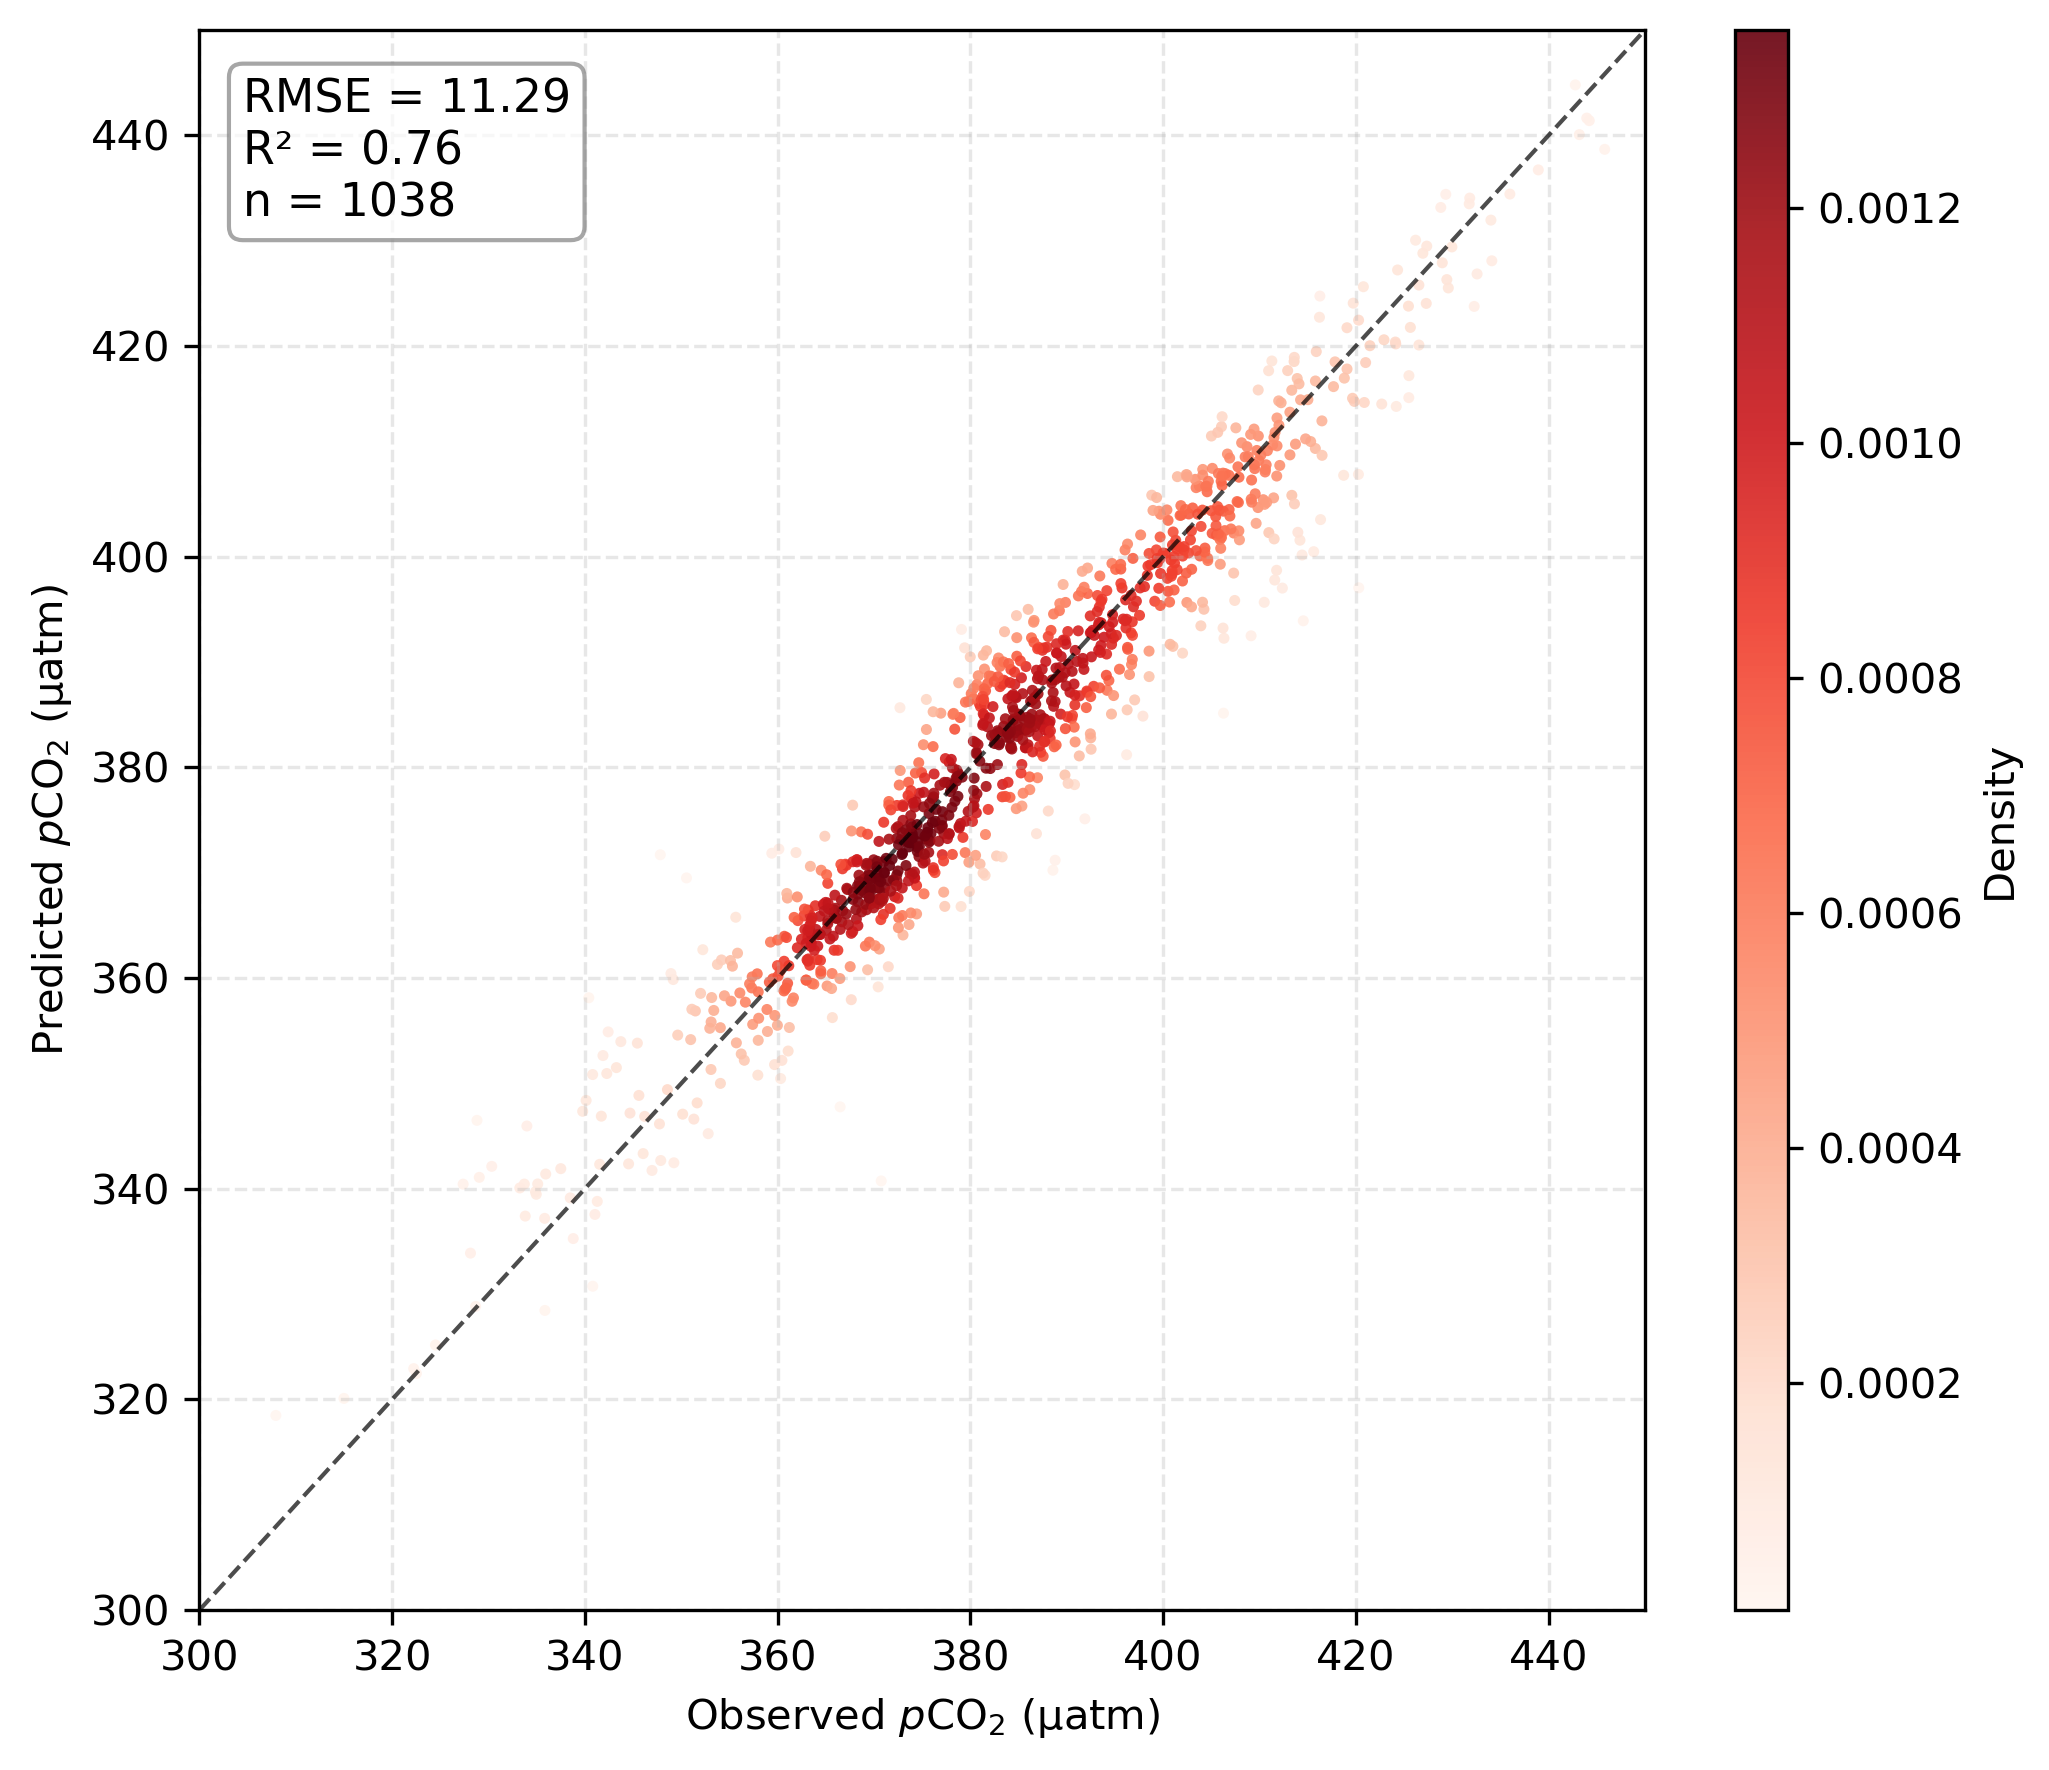

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import gaussian_kde

# -------------------------------
# Select only needed columns and drop NaNs
# -------------------------------
df_valid = df[['FLOATS_pco2_median', 'ensemble_pco2_pred']].dropna()

x = df_valid['FLOATS_pco2_median'].values
y = df_valid['ensemble_pco2_pred'].values
n = len(df_valid)

# -------------------------------
# Compute point density using KDE
# -------------------------------
xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy)

# -------------------------------
# Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

sc = ax.scatter(
    x, y,
    c=density,
    s=7,
    alpha=0.9,
    edgecolor='none',
    cmap='Reds'
)

# Labels
ax.set_xlabel(r"Observed $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")
ax.set_ylabel(r"Predicted $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")
ax.grid(True, ls='--', alpha=0.3)

# -------------------------------
# 1:1 line
# -------------------------------
min_pco2 = min(300, 300)
max_pco2 = max(450, 450)

ax.plot(
    [min_pco2, max_pco2],
    [min_pco2, max_pco2],
    'k--',
    lw=1,
    alpha=0.7
)

# Axis limits
ax.set_xlim(300, 450)
ax.set_ylim(300, 450)

# -------------------------------
# Colorbar
# -------------------------------
cbar = fig.colorbar(sc, ax=ax, label='Density', aspect=30)

# -------------------------------
# Metrics (NaN-safe, sklearn-safe)
# -------------------------------
rmse = np.sqrt(mean_squared_error(x, y))
r2 = r2_score(x, y)

# -------------------------------
# Stats box
# -------------------------------
stats_text = f"RMSE = {rmse:.2f}\nR² = {r2:.2f}\nn = {n}"

ax.text(
    0.03, 0.97, stats_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.7)
)

# -------------------------------
# Save and show
# -------------------------------
fig.tight_layout()
fig.savefig("figs/pco2_density_scatter.png", dpi=300, bbox_inches='tight')
plt.show()


In [8]:
import numpy as np
from sklearn.metrics import mean_squared_error

# -------------------------------
# Ensure NaN-safe inputs
# -------------------------------
mask = np.isfinite(x) & np.isfinite(y)
x_valid = x[mask]
y_valid = y[mask]

# -------------------------------
# Compute RMSE (sklearn v1.5+ compatible)
# -------------------------------
rmse = np.sqrt(mean_squared_error(x_valid, y_valid))

# -------------------------------
# Absolute prediction error
# -------------------------------
abs_error = np.abs(y_valid - x_valid)

# -------------------------------
# Count how many errors are within ±RMSE
# -------------------------------
within_rmse = np.sum(abs_error <= rmse)

# -------------------------------
# Percentage
# -------------------------------
pct_within_rmse = (within_rmse / len(x_valid)) * 100

# -------------------------------
# Output
# -------------------------------
print(f"RMSE: {rmse:.2f} µatm")
print(f"Percentage of observations within ±RMSE: {pct_within_rmse:.2f}%")
print(f"Count: {within_rmse} out of {len(x_valid)}")


RMSE: 11.29 µatm
Percentage of observations within ±RMSE: 95.18%
Count: 988 out of 1038


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from sklearn.metrics import mean_squared_error

# --- Season assignment function ---
def get_season(month):
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    elif month in [9, 10, 11]:
        return 'Spring'

# --- Convert month_center to datetime ---
df['month_center'] = pd.to_datetime(df['month_center'], errors='coerce')

# --- Extract month ---
df['month'] = df['month_center'].dt.month

# --- Assign season ---
df['season'] = df['month'].apply(get_season)

# -------------------------------
# NaN-safe global KDE scaling
# -------------------------------

# Select only required columns and drop NaNs
df_valid = df[['FLOATS_pco2_median', 'ensemble_pco2_pred']].dropna()

all_x = df_valid['FLOATS_pco2_median'].values
all_y = df_valid['ensemble_pco2_pred'].values

# Stack safely
xy = np.vstack([all_x, all_y])

# Compute global density
all_density = gaussian_kde(xy)(xy)

# Global color scale limits
global_vmin = all_density.min()
global_vmax = all_density.max()

print("Done: global density range =", global_vmin, global_vmax)


Done: global density range = 6.799055044499648e-06 0.0013510703368717978


/tmp/ipykernel_2233799/1927677425.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


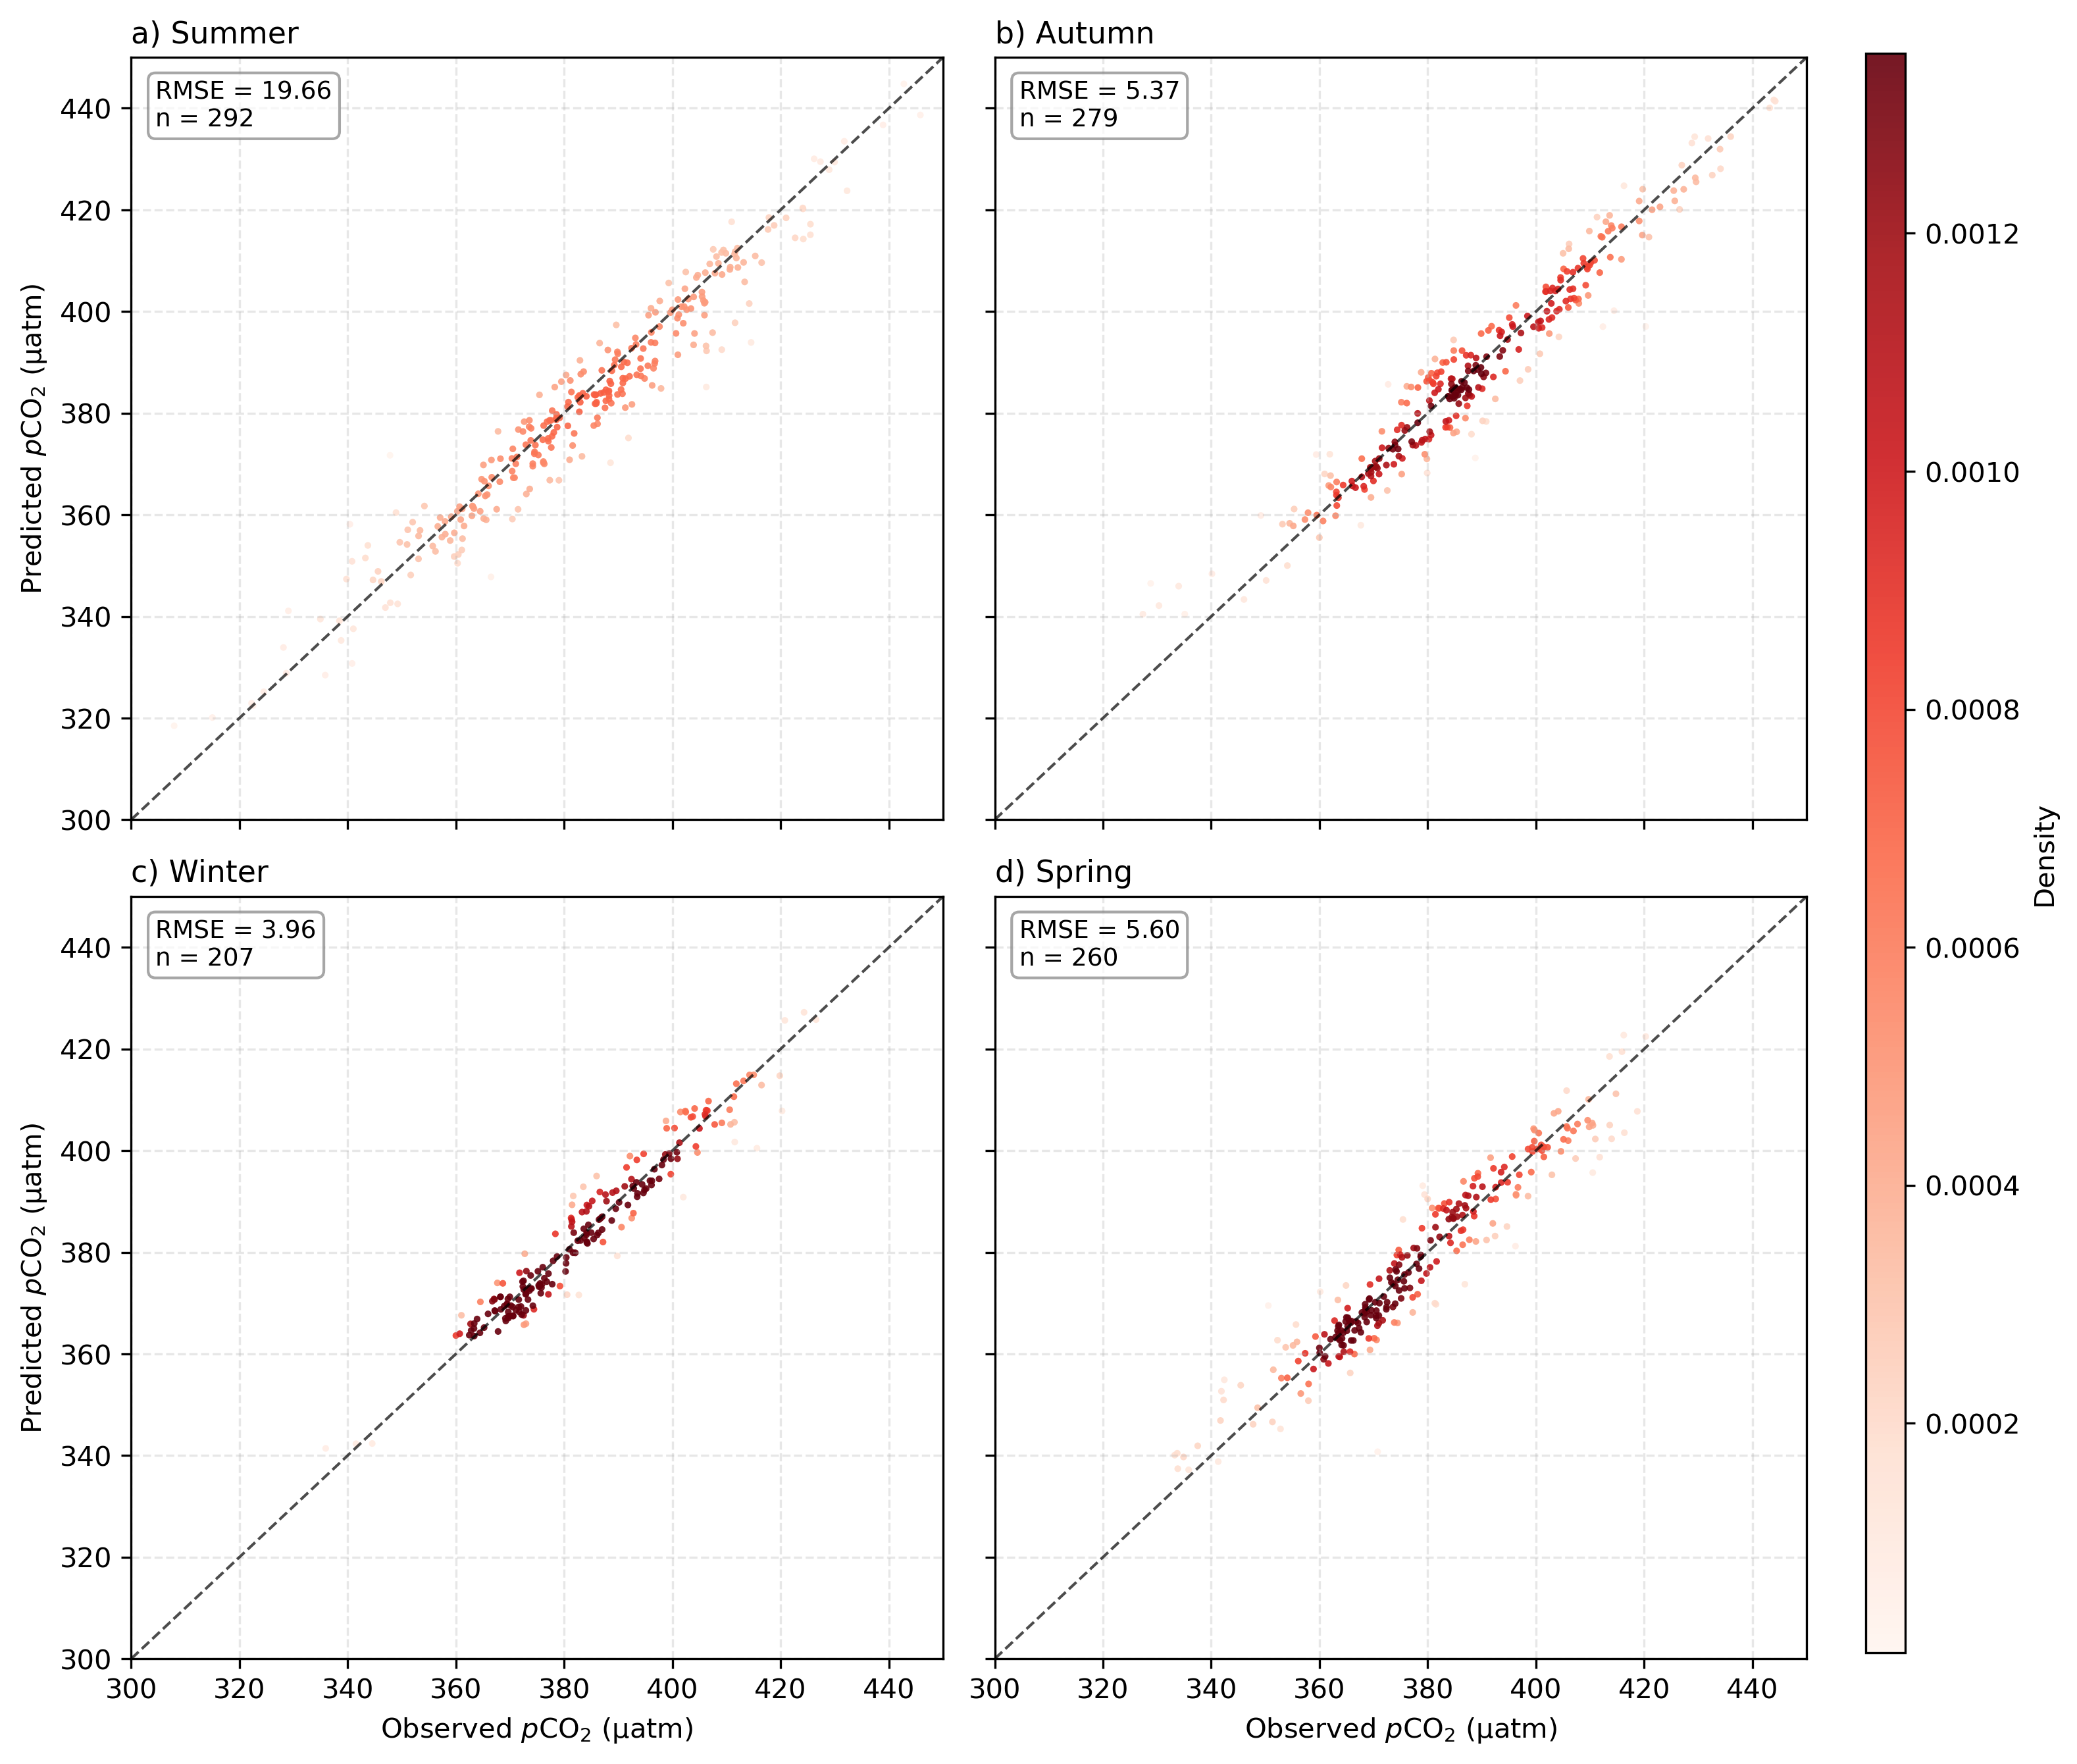

In [10]:
# Prepare subplot grid
fig, axs = plt.subplots(2, 2, figsize=(10, 9), dpi=300, sharex=True, sharey=True)
axs = axs.flatten()

season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
letters = ['a) Summer', 'b) Autumn', 'c) Winter', 'd) Spring']
xlim = ylim = (300, 450)

for i, season in enumerate(season_order):
    ax = axs[i]

    # -------------------------------
    # Select season & drop NaNs safely
    # -------------------------------
    data = df.loc[df['season'] == season, ['FLOATS_pco2_median', 'ensemble_pco2_pred']].dropna()

    # If too few points, skip safely
    if len(data) < 5:
        ax.text(
            0.5, 0.5, f"{season}\nNot enough data",
            transform=ax.transAxes,
            ha='center',
            va='center',
            fontsize=10
        )
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.grid(True, ls='--', alpha=0.3)
        continue

    x = data['FLOATS_pco2_median'].values
    y = data['ensemble_pco2_pred'].values

    # -------------------------------
    # KDE density (NaN-safe)
    # -------------------------------
    xy = np.vstack([x, y])
    density = gaussian_kde(xy)(xy)

    idx = density.argsort()
    x, y, density = x[idx], y[idx], density[idx]

    # -------------------------------
    # Scatter plot
    # -------------------------------
    sc = ax.scatter(
        x, y,
        c=density,
        s=6,
        alpha=0.9,
        edgecolor='none',
        cmap='Reds',
        vmin=global_vmin,
        vmax=global_vmax
    )

    # -------------------------------
    # Axes setup
    # -------------------------------
    if i % 2 == 0:
        ax.set_ylabel(r"Predicted $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")
    if i >= 2:
        ax.set_xlabel(r"Observed $p\mathrm{CO}_2$ $\mathrm{(\mu atm)}$")

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(True, ls='--', alpha=0.3)

    # -------------------------------
    # 1:1 line
    # -------------------------------
    ax.plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], 'k--', lw=1, alpha=0.7)

    # -------------------------------
    # Metrics (sklearn v1.5+ compatible)
    # -------------------------------
    rmse = np.sqrt(mean_squared_error(x, y))
    n = len(x)

    # -------------------------------
    # Stats box
    # -------------------------------
    stats_text = f"RMSE = {rmse:.2f}\nn = {n}"

    ax.text(
        0.03, 0.97,
        stats_text,
        transform=ax.transAxes,
        fontsize=9,
        va='top',
        ha='left',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
    )

    # -------------------------------
    # Panel label
    # -------------------------------
    ax.text(
        0, 1.05,
        letters[i],
        transform=ax.transAxes,
        fontsize=11,
        va='top',
        ha='left'
    )

# -------------------------------
# Shared colorbar
# -------------------------------
cbar_ax = fig.add_axes([0.95, 0.068, 0.02, 0.9])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Density')

# -------------------------------
# Final layout and save
# -------------------------------
fig.tight_layout()
fig.subplots_adjust(right=0.92)
fig.savefig("figs/pco2_density_by_season.png", dpi=300, bbox_inches='tight')
plt.show()
